# Binance API for more crypto coins and minute bar data
1. Install python-binance: pip install python-binance
2. Documentation: https://python-binance.readthedocs.io/en/latest/
3. GitHub: https://github.com/sammchardy/python-binance

# Importing required packages

In [50]:
# Important packages to import
import pandas as pd 
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression 

# Data Collection
This step involves downloading the required crytocurrency data using Binance API in US currency. In this preliminary work, we will not use Arbitrage strategy to check with value in other currencies.

In [51]:
# Need not run if already have the pickle files
'''
from binance.client import Client as bnb_client

client = bnb_client(tld='US')
###  if you're in the US, use: 
### "client = bnb_client(tld='US')" here instead

def get_binance_px(symbol,freq,start_ts = '2020-01-01', end_ts = '2025-12-31'):
    data = client.get_historical_klines(symbol,freq,start_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']
    data = pd.DataFrame(data,columns = columns)
    # Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
    data['open_time'] = data['open_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
    data['close_time'] = data['close_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
    return data 

univ = ['BTCUSDT', 'ETHUSDT', 'ADAUSDT','BNBUSDT','XRPUSDT','DOTUSDT','MATICUSDT']
freq = '4h'
for x in univ:
    data = get_binance_px(x, freq)
    name = x + '_1d.pkl'
    data.to_pickle(name)
'''

'\nfrom binance.client import Client as bnb_client\n\nclient = bnb_client(tld=\'US\')\n###  if you\'re in the US, use: \n### "client = bnb_client(tld=\'US\')" here instead\n\ndef get_binance_px(symbol,freq,start_ts = \'2020-01-01\', end_ts = \'2025-12-31\'):\n    data = client.get_historical_klines(symbol,freq,start_ts)\n    columns = [\'open_time\',\'open\',\'high\',\'low\',\'close\',\'volume\',\'close_time\',\'quote_volume\',\n    \'num_trades\',\'taker_base_volume\',\'taker_quote_volume\',\'ignore\']\n    data = pd.DataFrame(data,columns = columns)\n    # Convert from POSIX timestamp (number of millisecond since jan 1, 1970)\n    data[\'open_time\'] = data[\'open_time\'].map(lambda x: datetime.utcfromtimestamp(x/1000))\n    data[\'close_time\'] = data[\'close_time\'].map(lambda x: datetime.utcfromtimestamp(x/1000))\n    return data \n\nuniv = [\'BTCUSDT\', \'ETHUSDT\', \'ADAUSDT\',\'BNBUSDT\',\'XRPUSDT\',\'DOTUSDT\',\'MATICUSDT\']\nfreq = \'4h\'\nfor x in univ:\n    data = get_binan

In [52]:
# Code to extract the dataframe stored as Pickle files in the folder path
file_path = 'Pkl_Files/BTCUSDT_4h.pkl'
file_path_1d = 'Pkl_Files/BTCUSDT_1d.pkl'
data_btc = pd.read_pickle(file_path)
data_btc_1d = pd.read_pickle(file_path_1d)

In [53]:
# Converting the closing time price-data into float instead of string for regular mathematical operations
data_btc.loc[:,'close'] = data_btc.loc[:,'close'].astype(float)
data_btc_1d.loc[:,'close'] = data_btc_1d.loc[:,'close'].astype(float)

In [54]:
# Fraction return of bitcoin after every 4 hours
ret = data_btc["close"] / data_btc["close"].shift() - 1

## Define Backtest Data
Backtest data is used as the first 70% of the data to find the best parameters for the strategy. It is assumed that the present time is the data one time unit after the backtest data and we have no access to the future data. Upon optimization of strategy, the strategy would then be tested against the available 30% of the data to see how well the strategy works compared to S&P500 and base-case of just holding the bitcoin.

In [55]:
# Define backtest data. Use this data only to train different strategies. Then use the strategies to predict for the rest of the data
# We will use 70% of the available data as backtest data. Rest of the data will be used for testing the strategies in real time.
ind = int(data_btc.count()[0]*0.7)
data_BT = data_btc.loc[1:ind, :]
# Return of bitcoin per dollar after every 4 hours
ret_BT = data_BT["close"] / data_BT["close"].shift() - 1

/var/folders/63/jgs1r5x966xcvf9q4_wbmp940000gn/T/ipykernel_21910/1924955683.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ind = int(data_btc.count()[0]*0.7)


In [56]:
# Define function "Properties" to output the desired properties
def Properties(ret, A, freq=4):
    A["Mean"] = ret.mean()
    A["Sharpe"] = ret.mean() / ret.std() * np.sqrt(252*24/freq)
    A["Volatility"] = ret.std() * np.sqrt(252*24/freq)
    A["Hit_Rate"] = sum(ret.map(lambda x: 1 if x > 0 else 0))/ret.count()*100

# Strategy 1
The first basic strategy would be buy a bitcoin at the start of the period and hold it throughout. This is the base-level strategy that would be used to compare the strategies used later.

The mean profit per 4 hours is  0.0005019720455211753
The Sharpe is  1.0997976728294423
The Volatility is  0.6901103280891564
The Hit rate per 4 hours is  51.578161654937084


<Axes: >

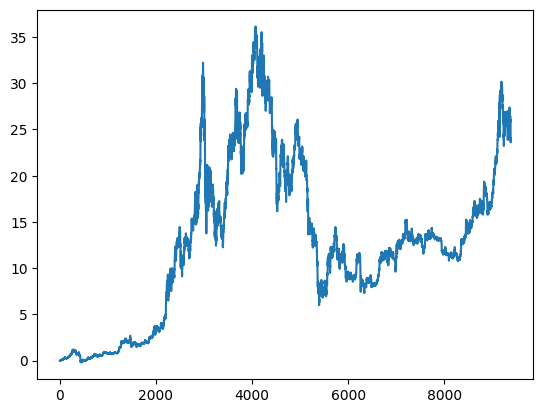

In [139]:
base_strats = {}
Properties(ret_BT, base_strats)
print("The mean profit per 4 hours is ", base_strats['Mean'])
print("The Sharpe is ", base_strats['Sharpe'])
print("The Volatility is ", base_strats['Volatility'])
print("The Hit rate per 4 hours is ", base_strats['Hit_Rate'])
((1+ret_BT).cumprod()-1).plot()

The mean profit per 4 hours is  -2.084317858360976e-05
The Sharpe is  -0.055020422706898164
The Volatility is  0.5727852398790603
The Hit rate per 4 hours is  50.572424091587855


<Axes: >

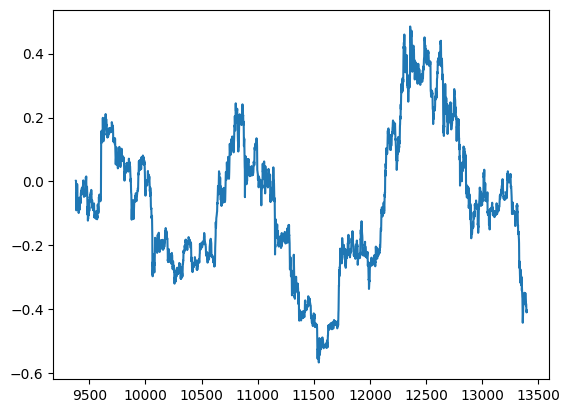

In [141]:
Properties(ret[ind+1:-1], base_strats)
print("The mean profit per 4 hours is ", base_strats['Mean'])
print("The Sharpe is ", base_strats['Sharpe'])
print("The Volatility is ", base_strats['Volatility'])
print("The Hit rate per 4 hours is ", base_strats['Hit_Rate'])
((1+ret[ind+1:-1]).cumprod()-1).plot()

### Computing net returns
Net returns would be computed as: net returns = (gross returns) - (transaction cost). It will be assumed that for every transaction, 20 basis points (bps) would be deducted. For buy and hold strategy, bitcoin is purchased only once. Therefore only 20 basis points at the start will be deducted.

In [93]:
data_btc.count()["open"]

np.int64(13399)

The net return of this strategy is:  Position    4.635087
dtype: object


<Axes: >

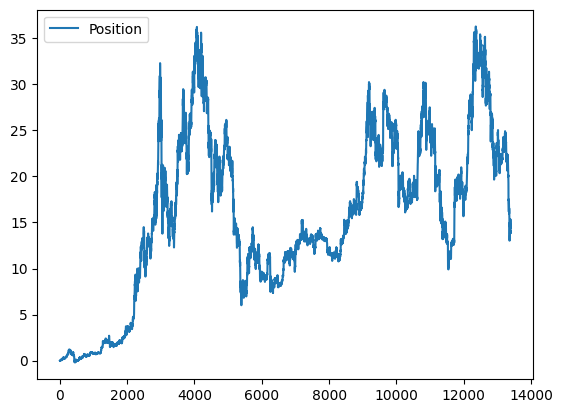

In [142]:
position = pd.DataFrame(np.ones((data_btc.count()["open"],1)), columns=["Position"])
position.iloc[0] -= 20*0.0001
ret_adj = position.multiply(ret, axis=0)
net_ret = ret_adj.sum()
print("The net return of this strategy is: ", net_ret)
((1+ret_adj).cumprod()-1).plot()

# Strategy 2: Momentum based strategy 
The strategy involves looking back X days in the past and seeing the returns. If the return given by: <br>
$ret = P_t/P_{t-L} - 1 > 0$ <br>
, then long the position , i.e. buy bitcoin. If it is negative, then cash out bitcoin, i.e. sell it. <br>
This is a simple strategy that we will implement first to see how well a basic momentum strategy works for bitcoin. <br>
This strategy involves the following parameters:
* look_back1: This variable is the endpoint of the period of which momentum we would be interested in.
* look_back2: This variable is the startpoint of the period of which momentum we would be interested in.
* thres: If the return between look_back1 and look_back2 is above this threshold, buy the stock. Otherwise sell it
* data: The price-time data for the stock
* ret_BT: The returns for the stock

In addition, bitcoin daily price data can be very volatile. As a result, as an another strategy, we will utilize using past X days (typically 15 days) moving average and comparing it with past Y days (typically a year) moving average to reduce stochasticities and capture overall trends for momentum.

In addition, we will also test different types of signals, the first being binary signal (buy or sell) - if momentum > threshold, buy/hold otherwise sell and the second signal being a z-score passed through tanh function to constrain holding between 0 and 1 (negative values will be interpreted as 0, i.e. sell).

## Strategy 2A: Using raw price-time data without moving averages using binary signal

The mean profit per 4 hours is  0.0004845843076804016
The Sharpe is  1.3966180278009266
The Volatility is  0.5246183699679443
The Hit rate per 4 hours is  30.443591384090425


<Axes: >

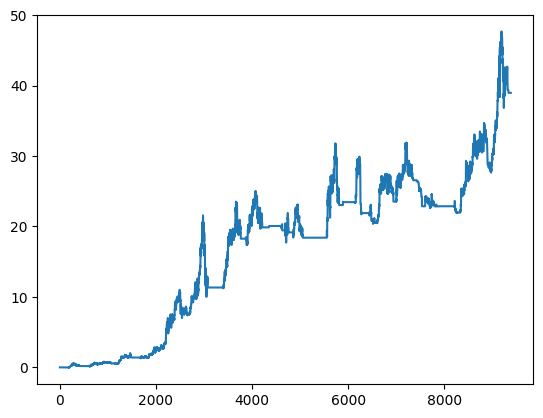

In [143]:
look_back = 30*6 # Let us say look back period is 20 days. Multiplied 6 as the data is for every four hours and not a day.
def Mom_Strat1(look_back1, look_back2, thres, data, ret_BT):
    momentum = data['close'].shift(look_back1) - data['close'].shift(look_back2)
    signal = momentum.map(lambda x: 1 if x > thres else 0)
    position = signal.shift(1)
    ret_mom1 = position*ret_BT
    return ret_mom1, position
ret_mom1, pos_mom1 = Mom_Strat1(0, look_back, 0, data_BT, ret_BT)
mom_strats1 = {}
Properties(ret_mom1, mom_strats1)
print("The mean profit per 4 hours is ", mom_strats1['Mean'])
print("The Sharpe is ", mom_strats1['Sharpe'])
print("The Volatility is ", mom_strats1['Volatility'])
print("The Hit rate per 4 hours is ", mom_strats1['Hit_Rate'])
((1+ret_mom1).cumprod()-1).plot()

In [107]:
# Plotting the Sharpe ratio as a function of look back period
look_back_arr = range(0,600,60)
thres_arr = [x / 100.0 for x in range(0, 11)]
Sharpe = np.zeros([len(look_back_arr), len(look_back_arr), len(thres_arr)])
best_lookback_init = 0
best_lookback_final = 0
best_lookback_thres = 0
best_Sharpe = 0
for i in range(0, len(look_back_arr)):
    for j in range(i+1, len(look_back_arr)):
        for k in range(0, len(thres_arr)):
            ret_i, pos_i = Mom_Strat1(look_back_arr[i], look_back_arr[j], thres_arr[k], data_BT, ret_BT)
            strat = {}
            Properties(ret_i, strat)
            Sharpe[i,j,k] = strat["Sharpe"]
            if Sharpe[i,j,k] > best_Sharpe:
                best_lookback_init = i
                best_lookback_final = j
                best_lookback_thres = k
                best_Sharpe = Sharpe[i,j,k]


### Computing transaction cost

In [145]:
pos_mom1 = pos_mom1.fillna(0)
turnover = abs(pos_mom1 - pos_mom1.shift().fillna(0))
pos_mom1 = pos_mom1 - turnover*0.002
ret_adj_mom1 = pos_mom1.multiply(ret_BT, axis=0)
print((1+ret_adj_mom1).prod()-1)
mom1_adj_strat = {}
Properties(ret_adj_mom1, mom1_adj_strat)
mom1_adj_strat

38.99616831537903


{'Mean': np.float64(0.00048465786197019416),
 'Sharpe': np.float64(1.3969236465557795),
 'Volatility': np.float64(0.5245832076117501),
 'Hit_Rate': np.float64(31.552569844316487)}

### Finding the Drawdown duration and Drawdown value

Max Drawdown: -51.17%
Max draw down duration is  1510


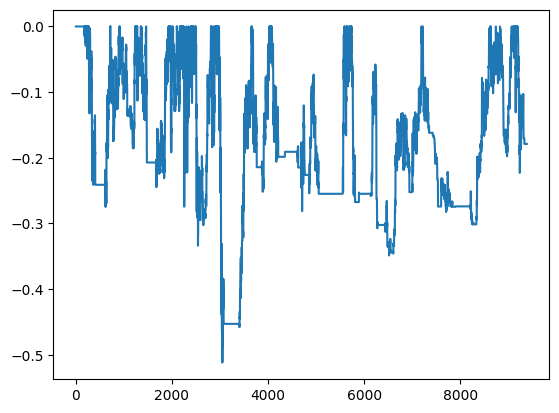

In [156]:
def CalculateDrawdown(ret):
    drawdown = (1 + ret).cumprod() / (1 + ret).cumprod().cummax() - 1
    drawdown.plot()
    max_dd = drawdown.min()
    print(f"Max Drawdown: {max_dd:.2%}")
    underwater = drawdown < 0
    drawdown_duration = underwater.groupby((~underwater).cumsum()).cumsum()
    max_dd_duration = drawdown_duration.max()
    print("Max draw down duration is ", max_dd_duration)
CalculateDrawdown(ret_adj_mom1)

Max Drawdown: -51.21%
Max draw down duration is  1510


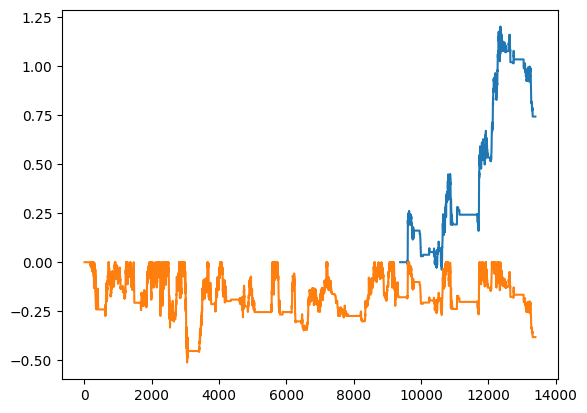

In [159]:
# Testing the strategy on days after the training index
ret_mom1_test, pos_mom1_test = Mom_Strat1(look_back_arr[best_lookback_init],look_back_arr[best_lookback_final],thres_arr[best_lookback_thres], data_btc, ret)
mom_strats1_test = {}
Properties(ret_mom1_test[ind:-1], mom_strats1_test)
ret_mom1_test[ind:-1].cumsum().plot()
mom_strats1_test
CalculateDrawdown(ret_mom1_test)

The mean profit per 4 hours is  0.00014001873606933802
The Sharpe is  1.3966180278009284
The Volatility is  0.1515864214284764
The Hit rate per 4 hours is  30.443591384090425


<Axes: >

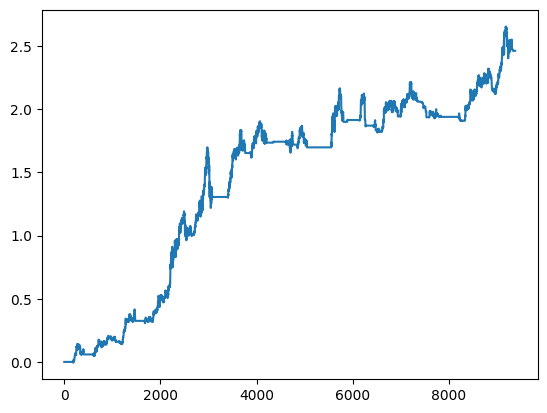

In [161]:
# Momentum strategy with volatility scaling
def Mom_Strat1_2(look_back1, look_back2, thres, data, ret_BT, target_vol):
    momentum = data['close'].shift(look_back1) - data['close'].shift(look_back2)
    signal = momentum.map(lambda x: 1 if x > thres else 0)
    scaling = min(1, target_vol/ret_BT.shift(look_back2).std()/np.sqrt(252*6))
    position = signal.shift(1)*scaling
    ret_mom1 = position*ret_BT
    return position, ret_mom1
look_back = 30*6 # Let us say look back period is 20 days. Multiplied 6 as the data is for every four hours and not a day.
ret_mom2_pos, ret_mom2 = Mom_Strat1_2(0, look_back, 0, data_BT, ret_BT, 0.2)
mom_strats2 = {}
Properties(ret_mom2, mom_strats2)
print("The mean profit per 4 hours is ", mom_strats2['Mean'])
print("The Sharpe is ", mom_strats2['Sharpe'])
print("The Volatility is ", mom_strats2['Volatility'])
print("The Hit rate per 4 hours is ", mom_strats2['Hit_Rate'])
((1+ret_mom2).cumprod()-1).plot()

## Strategy 2B: Using moving average price-time data using binary signal

The mean profit per 4 hours is  0.00039659288529891385
The Sharpe is  1.1026676717689596
The Volatility is  0.5438161088099818
The Hit rate per 4 hours is  33.354659842183835


<Axes: >

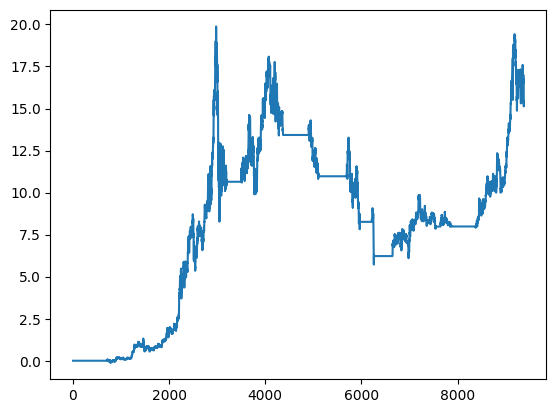

In [162]:
def Mom_Strat2(avg_back1, avg_back2, thres, data, ret_BT):
    momentum = data['close'].rolling(avg_back1).mean() - data['close'].rolling(avg_back2).mean()
    signal = momentum.map(lambda x: 1 if x > thres else 0)
    position = signal.shift(1)
    ret_mom1 = position*ret_BT
    return ret_mom1
avg_back1 = 10*6 # Let us say look back period is 20 days. Multiplied 6 as the data is for every four hours and not a day.
avg_back2 = 100*6
ret_mom2 = Mom_Strat2(avg_back1, avg_back2, 0, data_BT, ret_BT)
mom_strats1 = {}
Properties(ret_mom2, mom_strats2)
print("The mean profit per 4 hours is ", mom_strats2['Mean'])
print("The Sharpe is ", mom_strats2['Sharpe'])
print("The Volatility is ", mom_strats2['Volatility'])
print("The Hit rate per 4 hours is ", mom_strats2['Hit_Rate'])
((1+ret_mom2).cumprod()-1).plot()

Finding optimal set of parameters for this strategy

In [64]:
avg_back_arr = np.array(range(10, 500, 10))*6
thres_back_arr = np.array(range(-5, 5, 1))/10
MaxSharpe = 0
best_index = np.zeros([3])
for i in range(len(avg_back_arr)):
    for j in range(i+1, len(avg_back_arr)):
        for k in range(len(thres_back_arr)):
            ret_mom_avg = Mom_Strat2(avg_back_arr[i], avg_back_arr[j], thres_back_arr[k], data_BT, ret_BT)
            strat_prop = {}
            Properties(ret_mom_avg, strat_prop)
            if MaxSharpe < strat_prop["Sharpe"]:
                MaxSharpe = strat_prop["Sharpe"]
                best_index = np.array([i,j,k])

In [65]:
print("The max sharpe is", MaxSharpe, " for indices: ", best_index)

The max sharpe is 1.321133968875638  for indices:  [0 3 5]


Testing the strategy in test data

{'Mean': np.float64(0.00017143452524230235),
 'Sharpe': np.float64(0.7651627068868274),
 'Volatility': np.float64(0.3387632458212576),
 'Hit_Rate': np.float64(21.522766857427218)}

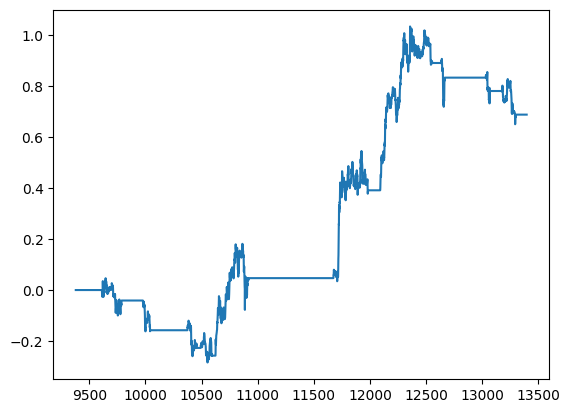

In [66]:
ret_mom2_test = Mom_Strat2(avg_back_arr[best_index[0]],avg_back_arr[best_index[1]],thres_back_arr[best_index[2]], data_btc, ret)
mom_strats2_test = {}
Properties(ret_mom2_test[ind:-1], mom_strats2_test)
ret_mom2_test[ind:-1].cumsum().plot()
mom_strats2_test

## Strategy 2C: Using raw price-time data with position holding using return z-value

The mean profit per 4 hours is  0.0004934871539218716
The Sharpe is  1.4094766603621696
The Volatility is  0.5293827118344362
The Hit rate per 4 hours is  31.039356381822138


<Axes: >

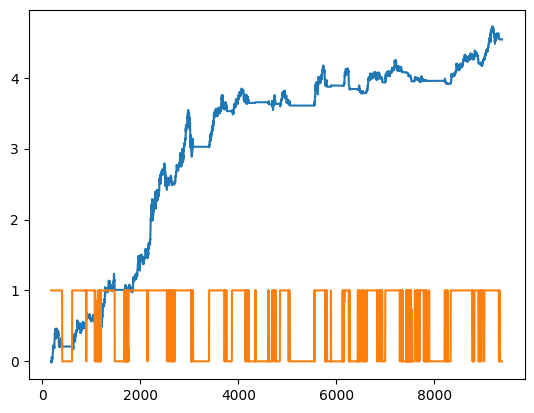

In [67]:
look_back = 30*6 # Let us say look back period is 20 days. Multiplied 6 as the data is for every four hours and not a day.
def Mom_Strat3(look_back1, look_back2, data, ret_BT):
    momentum = (data['close'].shift(look_back1) - data['close'].shift(look_back2))
    signal = momentum.map(lambda x: np.tanh(x))
    position = signal.map(lambda x: 0 if x<0 else x).shift(1)
    ret_mom1 = position*ret_BT
    return ret_mom1, position
ret_mom3, pos_mom3 = Mom_Strat3(0, look_back, data_BT, ret_BT)
mom_strats3 = {}
Properties(ret_mom3, mom_strats3)
print("The mean profit per 4 hours is ", mom_strats3['Mean'])
print("The Sharpe is ", mom_strats3['Sharpe'])
print("The Volatility is ", mom_strats3['Volatility'])
print("The Hit rate per 4 hours is ", mom_strats3['Hit_Rate'])
ret_mom3.cumsum().plot()
pos_mom3.plot()

{'Mean': np.float64(0.00018790087921633858),
 'Sharpe': np.float64(0.8390249418749458),
 'Volatility': np.float64(0.33861464087136656),
 'Hit_Rate': np.float64(20.701667081363524)}

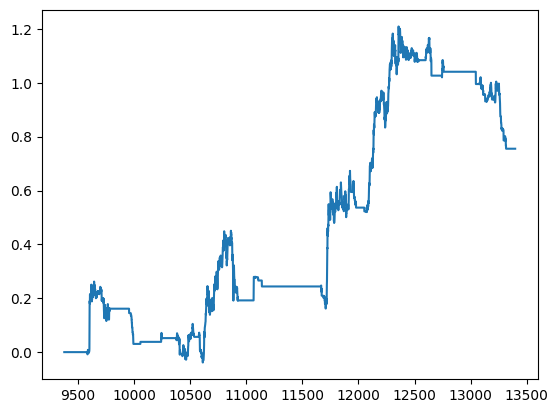

In [68]:
ret_mom3_test, pos_mom3_test = Mom_Strat3(0,look_back, data_btc, ret)
mom_strats3_test = {}
Properties(ret_mom3_test[ind:-1], mom_strats3_test)
ret_mom3_test[ind:-1].cumsum().plot()
mom_strats3_test

## Strategy 2D: Using average of the lookback and using tanh of z-value as bitcoin position

The mean profit per 4 hours is  0.0003704278732227118
The Sharpe is  1.0527398798250425
The Volatility is  0.5320278589672337
The Hit rate per 4 hours is  35.63048183164369


<Axes: >

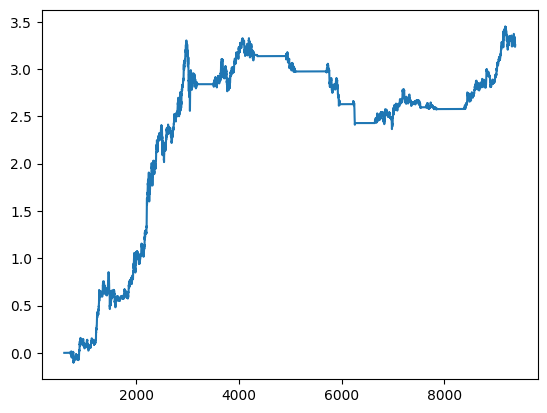

In [69]:
def Mom_Strat4(avg_back1, avg_back2, thres, data, ret_BT):
    momentum = np.tanh((data['close'].rolling(avg_back1).mean() - data['close'].rolling(avg_back2).mean())/data['close'].rolling(avg_back2).std()*np.sqrt(avg_back1/6))
    signal = momentum.map(lambda x: 0 if x < 0 else x)
    position = signal.shift(1)
    ret_mom1 = position*ret_BT
    return ret_mom1
avg_back1 = 10*6 # Let us say look back period is 20 days. Multiplied 6 as the data is for every four hours and not a day.
avg_back2 = 100*6
ret_mom4 = Mom_Strat4(avg_back1, avg_back2, 0, data_BT, ret_BT)
mom_strats4 = {}
Properties(ret_mom4, mom_strats4)
print("The mean profit per 4 hours is ", mom_strats4['Mean'])
print("The Sharpe is ", mom_strats4['Sharpe'])
print("The Volatility is ", mom_strats4['Volatility'])
print("The Hit rate per 4 hours is ", mom_strats4['Hit_Rate'])
ret_mom4.cumsum().plot()

# Reversal startegy
This strategy involves seeing the previous X number of returns. If the returns have gone down by Y percentage, buy Z amount of bitcoin. <br> If the price of bitcoin rises by A percentage, sell the bitcoin and cashout

{'Mean': np.float64(0.0003138632995147141), 'Sharpe': np.float64(1.0608326789914209), 'Volatility': np.float64(0.4473479355080138), 'Hit_Rate': np.float64(26.924717423757734)}


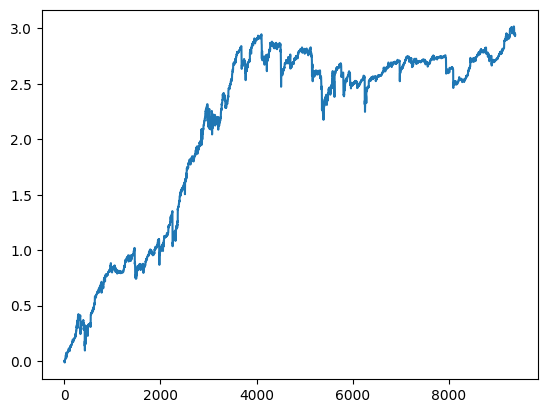

In [70]:
def rev_strat1(ret, window, thres, buy_increments):
    signal_rev = ret.rolling(window).sum()
    signal_rev.iloc[0] = 0
    for i in range(1,len(signal_rev)):
        if signal_rev.iloc[i] < 0 and signal_rev.iloc[i] > thres:
            if signal_rev.iloc[i-1] == 1:
                signal_rev.iloc[i] = 1
            else:
                signal_rev.iloc[i] = signal_rev.iloc[i-1] + buy_increments
        else:
            signal_rev.iloc[i] = max(0, signal_rev.iloc[i]-buy_increments)
    pos_rev = signal_rev.shift(1)
    ret_rev = pos_rev*ret
    return ret_rev
ret_rev_BT = rev_strat1(ret_BT, 1, -0.5, 0.4)
rev_strat = {}
Properties(ret_rev_BT, rev_strat)
ret_rev_BT.cumsum().plot()
print(rev_strat)

{'Mean': np.float64(-0.0001711850331987109), 'Sharpe': np.float64(-0.6162890050616395), 'Volatility': np.float64(0.4199844035357458), 'Hit_Rate': np.float64(25.535092085614735)}


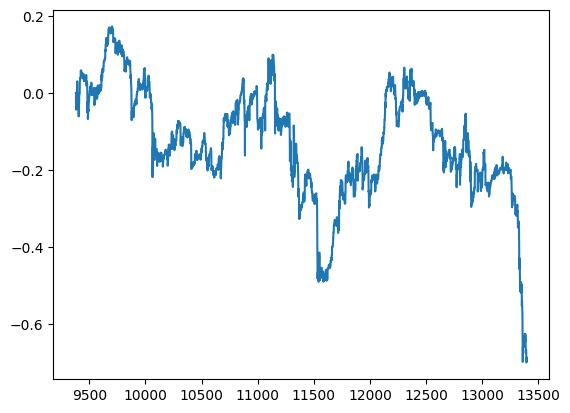

In [71]:
# Testing the strategy on test data
ret_rev_test = rev_strat1(ret, 1, -0.5, 1)[ind+1:-1]
rev_test = {}
Properties(ret_rev_test, rev_test)
ret_rev_test.cumsum().plot()
print(rev_test)

In [72]:
# Need to find alpha and beta compared to S&P 500
# Only 1 day data is available for S&P500. Therefore, need to convert the bitcoin 4h data to 1 day data to find the correlation
import yfinance as yf
ticker = "^GSPC"
data = yf.Ticker(ticker)
hist = data.history(start='2020-01-01', end = '2025-12-31') 


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/yfinance/utils.py:472: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["Adj Open"] = df["Open"] * ratio
/Library/Frameworks/Python.framework/Versions/3.14/lib/p

In [73]:
data_sp500 = hist["Close"]
ret_snp = data_sp500 / data_sp500.shift(1) - 1
ret_snp.index = ret_snp.index.date
# Calculate 1 day return for bitcoin
data_btc_1d_up = data_btc_1d.copy()
data_btc_1d_up["close_time"] = data_btc_1d_up["close_time"].dt.normalize()
data_btc_1d_up = data_btc_1d_up.set_index("close_time")
ret_btc_1d = data_btc_1d_up["close"]/data_btc_1d_up["close"].shift(1) - 1
ret_snp = ret_snp.fillna(0.0)
ret_btc_1d = ret_btc_1d.fillna(0.0)
ret_snp.index = pd.to_datetime(ret_snp.index)



/var/folders/63/jgs1r5x966xcvf9q4_wbmp940000gn/T/ipykernel_21910/1243251544.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_btc_1d_up["close_time"] = data_btc_1d_up["close_time"].dt.normalize()
/var/folders/63/jgs1r5x966xcvf9q4_wbmp

<Axes: >

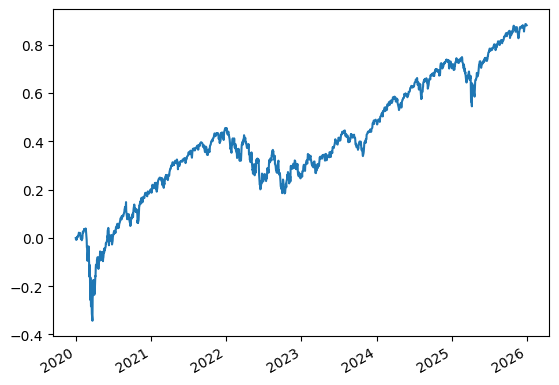

In [74]:
ret_snp.cumsum().plot()

In [75]:
common_idx = ret_snp.index.intersection(ret_btc_1d.index)
ret_snp_red = ret_snp.loc[common_idx]
ret_btc_1d_red = ret_btc_1d.loc[common_idx]


In [76]:
corr = ret_snp_red.corr(ret_btc_1d_red)

In [77]:
# Find alpha and beta of bitcoin with respect of S&P500
model = LinearRegression()
model.fit(ret_snp_red.values.reshape(-1, 1), ret_btc_1d_red.values)
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_}")
ret_1d_prop = {}
Properties(ret_btc_1d, ret_1d_prop,24)
ret_1d_prop

Intercept: 0.0014347460512344496
Coefficient: [1.036867]


{'Mean': np.float64(0.0015372530962638562),
 'Sharpe': np.float64(0.7544605876587354),
 'Volatility': np.float64(0.5134632432697978),
 'Hit_Rate': np.float64(50.84973166368515)}

In [78]:
# Find alpha and beta of best momentum strategy
ret_1d_mom = Mom_Strat1(look_back_arr[best_lookback_init],look_back_arr[best_lookback_final],thres_arr[best_lookback_thres], data_btc_1d_up, ret_btc_1d)
common_idx2 = ret_snp.index.intersection(ret_1d_mom.index)
ret_snp_red2 = ret_snp.loc[common_idx]
ret_1d_mom_red = ret_1d_mom.loc[common_idx]
corr2 = ret_snp_red2.corr(ret_1d_mom_red)
model2 = LinearRegression()
model2.fit(ret_snp_red2.values.reshape(-1, 1), ret_1d_mom_red.values)
print(f"Intercept: {model2.intercept_}")
print(f"Coefficient: {model2.coef_}")
ret_mom_1d_prop = {}
Properties(ret_1d_mom, ret_mom_1d_prop,24)
ret_mom_1d_prop

Intercept: 0.001114760748036607
Coefficient: [0.3491024]


{'Mean': np.float64(0.001265151728667673),
 'Sharpe': np.float64(0.8351969893948771),
 'Volatility': np.float64(0.38172819068139374),
 'Hit_Rate': np.float64(33.02013422818792)}

In [79]:
model3 = LinearRegression()
model.fit(ret_btc_1d_red.values.reshape(-1, 1), ret_1d_mom_red.values)
print(f"Intercept: {model2.intercept_}")
print(f"Coefficient: {model2.coef_}")

Intercept: 0.001114760748036607
Coefficient: [0.3491024]


In [80]:
# Find best partner of BTC to further increase Sharpe
# This would involve finding another cryptocurrency with negative correlation with bitcoin
File_Paths = ["Pkl_Files/ETHUSDT_4h.pkl", "Pkl_Files/ADAUSDT_4h.pkl", "Pkl_Files/BNBUSDT_4h.pkl", "Pkl_Files/DOTUSDT_4h.pkl", "Pkl_Files/MATICUSDT_4h.pkl", "Pkl_Files/XRPUSDT_4h.pkl",]
Coins = ["ETH", "ADA", "BNB", "DOT", "MATIC", "XRP"]
ret_cc = pd.DataFrame()
for i, j in zip(File_Paths, Coins):
    df = pd.read_pickle(i)
    df["close"].loc[:] = df["close"].loc[:].astype(float)
    ret_cc[j] = df["close"]/df["close"].shift(1) - 1
    corr = ret_cc[j].corr(ret)
    print("Correlation of ", i, " with BTC is: ", corr)

/var/folders/63/jgs1r5x966xcvf9q4_wbmp940000gn/T/ipykernel_21910/4079561124.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["close"].loc[:] = df["close"].loc[:].astype(float)
/var/folders/63/jgs1r5x966xcvf9q4_wbmp940000gn/T/ipykernel_

Correlation of  Pkl_Files/ETHUSDT_4h.pkl  with BTC is:  0.9999996179956488
Correlation of  Pkl_Files/ADAUSDT_4h.pkl  with BTC is:  0.7259790725763948
Correlation of  Pkl_Files/BNBUSDT_4h.pkl  with BTC is:  0.7178376293932464


/var/folders/63/jgs1r5x966xcvf9q4_wbmp940000gn/T/ipykernel_21910/4079561124.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["close"].loc[:] = df["close"].loc[:].astype(float)
/var/folders/63/jgs1r5x966xcvf9q4_wbmp940000gn/T/ipykernel_

Correlation of  Pkl_Files/DOTUSDT_4h.pkl  with BTC is:  0.005099202590077512
Correlation of  Pkl_Files/MATICUSDT_4h.pkl  with BTC is:  0.015487385288407048
Correlation of  Pkl_Files/XRPUSDT_4h.pkl  with BTC is:  0.17686154649536973


/var/folders/63/jgs1r5x966xcvf9q4_wbmp940000gn/T/ipykernel_21910/4079561124.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["close"].loc[:] = df["close"].loc[:].astype(float)
/var/folders/63/jgs1r5x966xcvf9q4_wbmp940000gn/T/ipykernel_

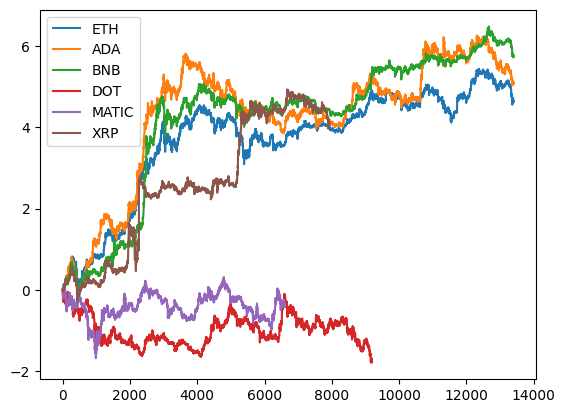

In [81]:
for i in Coins:
    ret_cc[i].cumsum().plot()
plt.legend(Coins)

In [82]:
# Since BNB and BTC have the least correlation with data available for the entire period, use it to form pair with BTC.
# First guess for the weights: Equal weighting
data_bnb = pd.read_pickle(File_Paths[2])
data_bnb["close"] = data_bnb["close"].astype(float)
ret_bnb = data_bnb["close"]/data_bnb["close"].shift() - 1
ret_comb = pd.DataFrame()
ret_comb["BNB"] = ret_bnb
ret_comb["BTC"] = ret

/var/folders/63/jgs1r5x966xcvf9q4_wbmp940000gn/T/ipykernel_21910/3468783628.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_bnb["close"] = data_bnb["close"].astype(float)


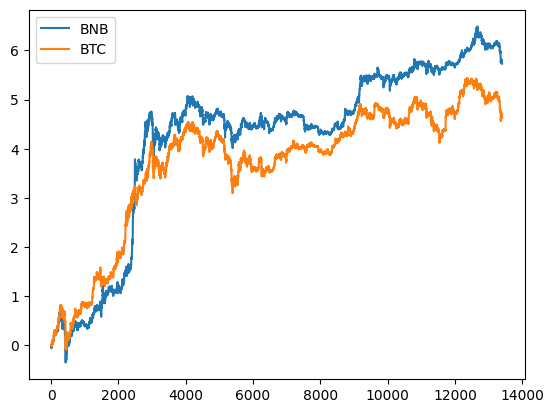

In [83]:
#BTC and BNB are very highly correlated. Therefore, there is not really any significance in pairing them up.
port_comb = pd.DataFrame(data=np.ones([13399,2])*0.5, columns=["BNB", "BTC"])
port_ret = ret_comb.multiply(port_comb).sum(axis=1)
ret_comb.cumsum(axis=0).plot()
plt.legend()